Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📥 Reading file: /content/drive/MyDrive/MLops/hyderabad_hotels.csv

🔹 Basic Info:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 123 entries, ('Taj Krishna Hyderabad', '4.5', '5000', '200') to ('The Conclave', '4.0', '7000', '160')
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Hotel Name                    123 non-null    object 
 1   Rating                        123 non-null    object 
 2   Price                         123 non-null    object 
 3   Total Reviews                 123 non-null    object 
 4   Review Summary                123 non-null    object 
 5   Location                      123 non-null    object 
 6   Distance from City Center     123 non-null    object 
 7   Booking Link                  123 non-null    object 
 8   Descript

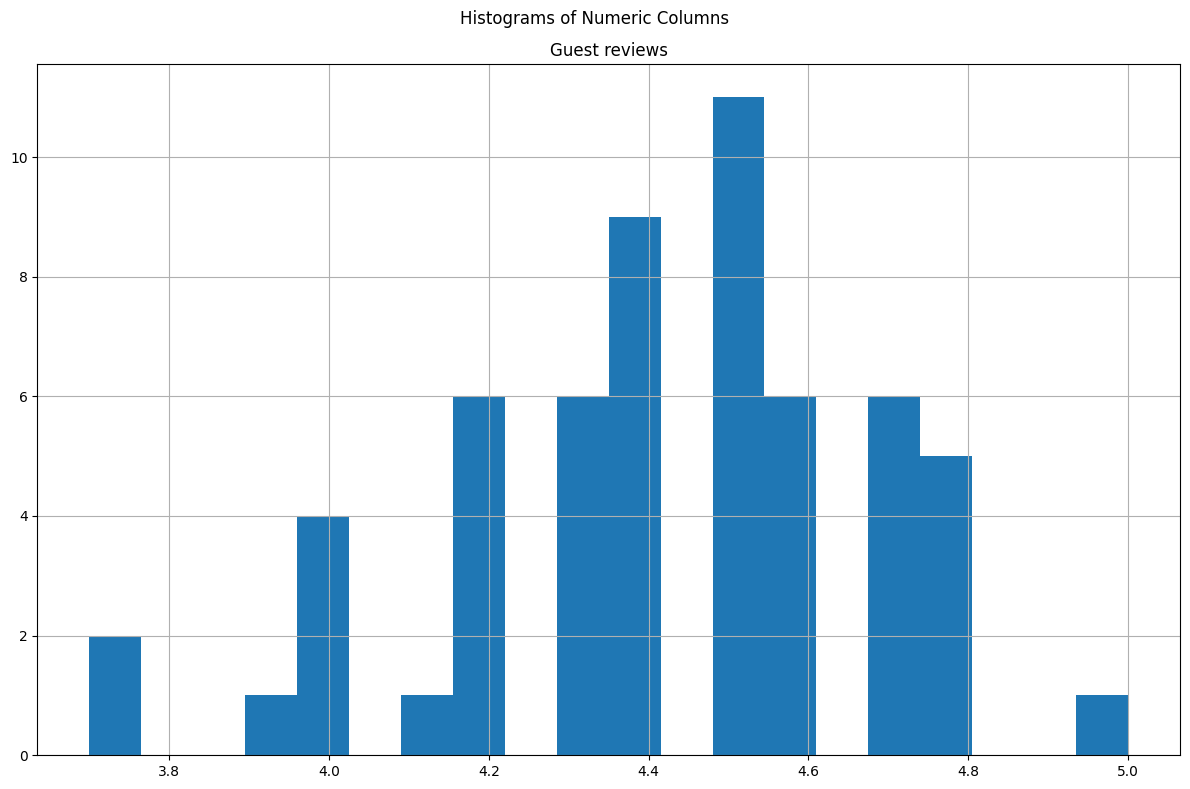

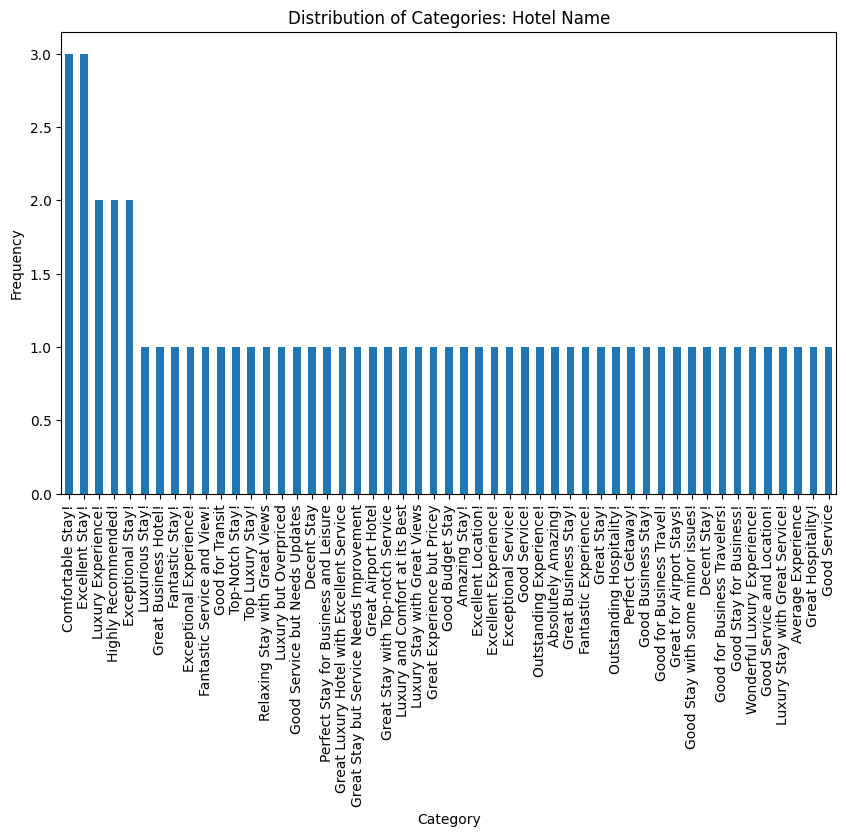

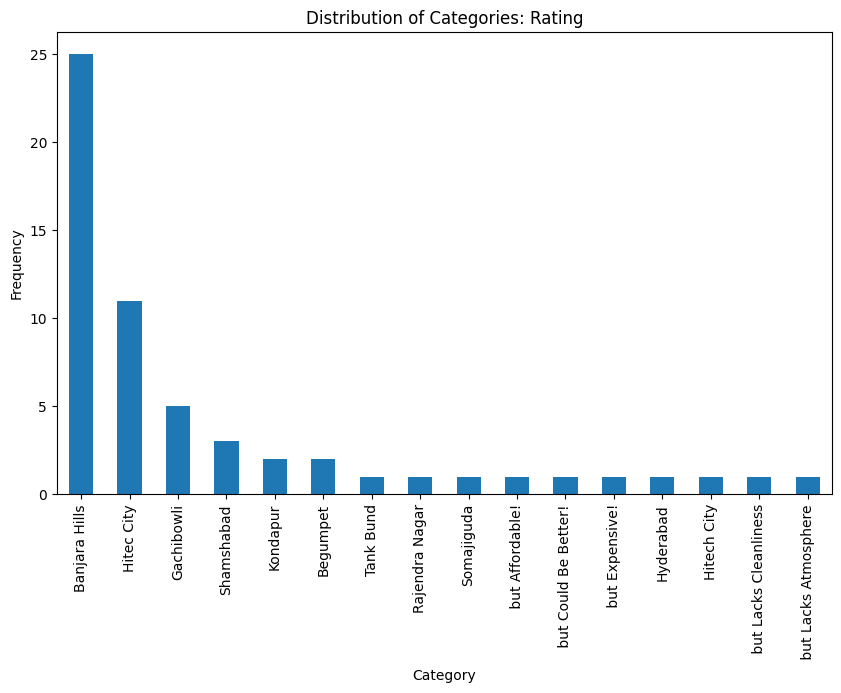

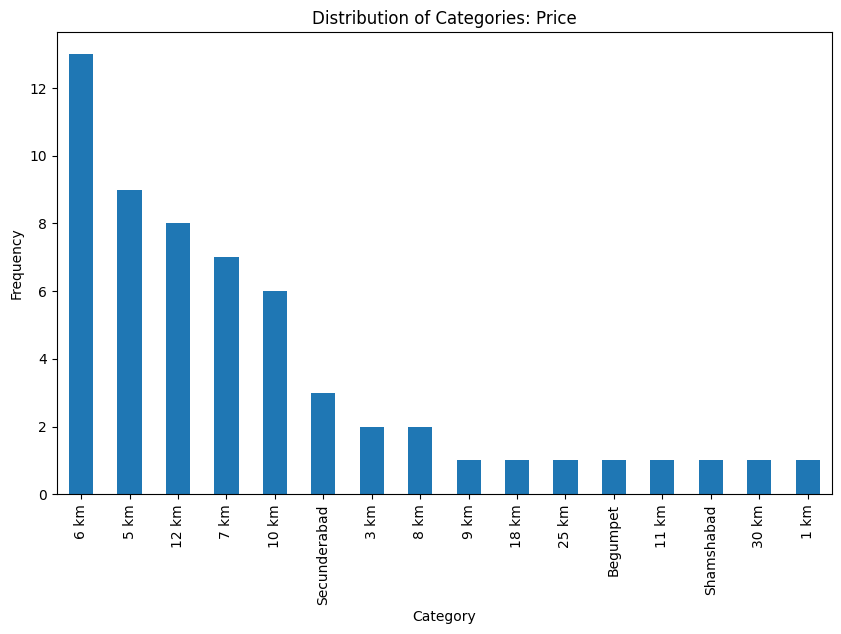

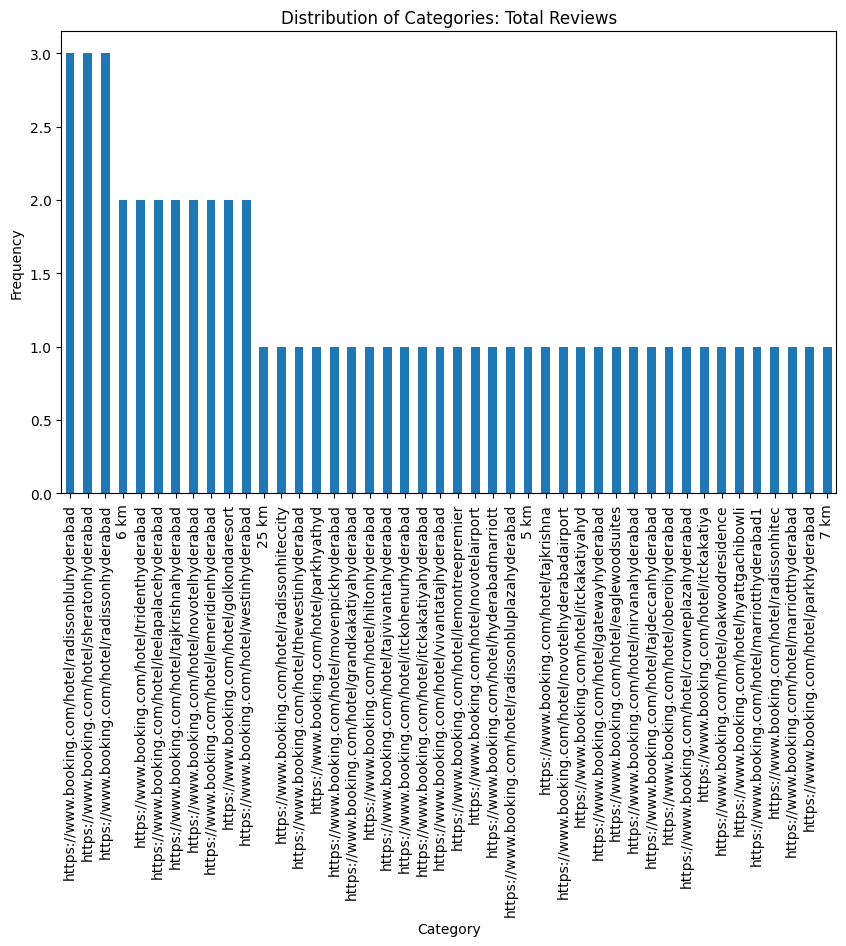

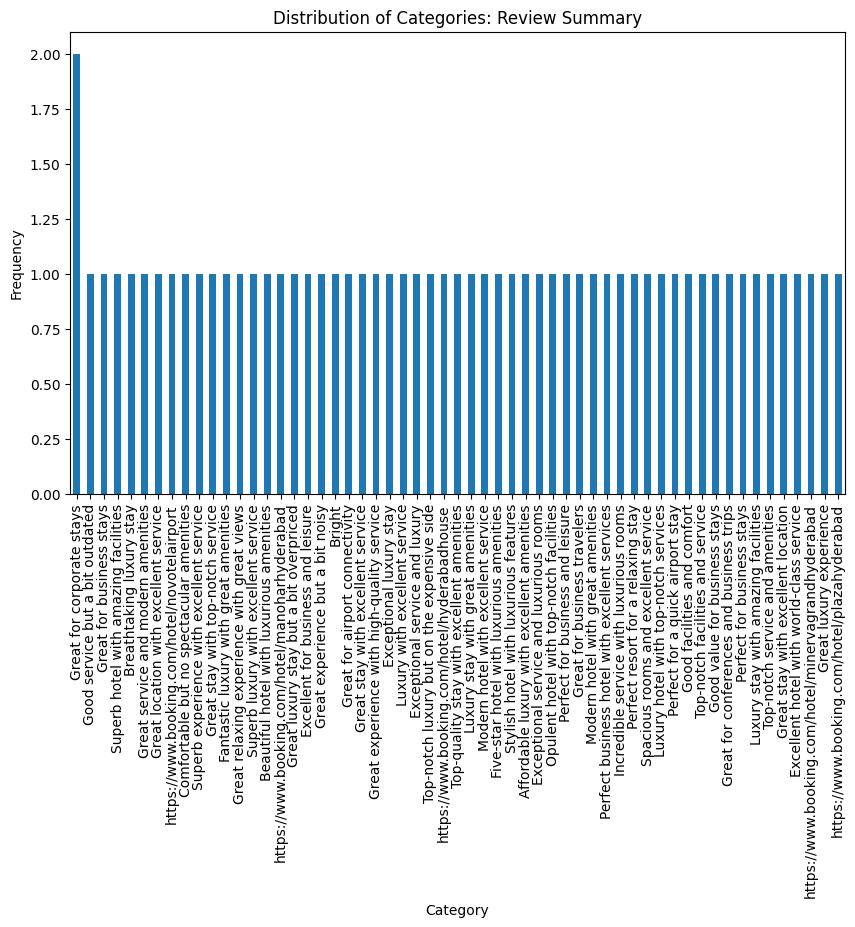

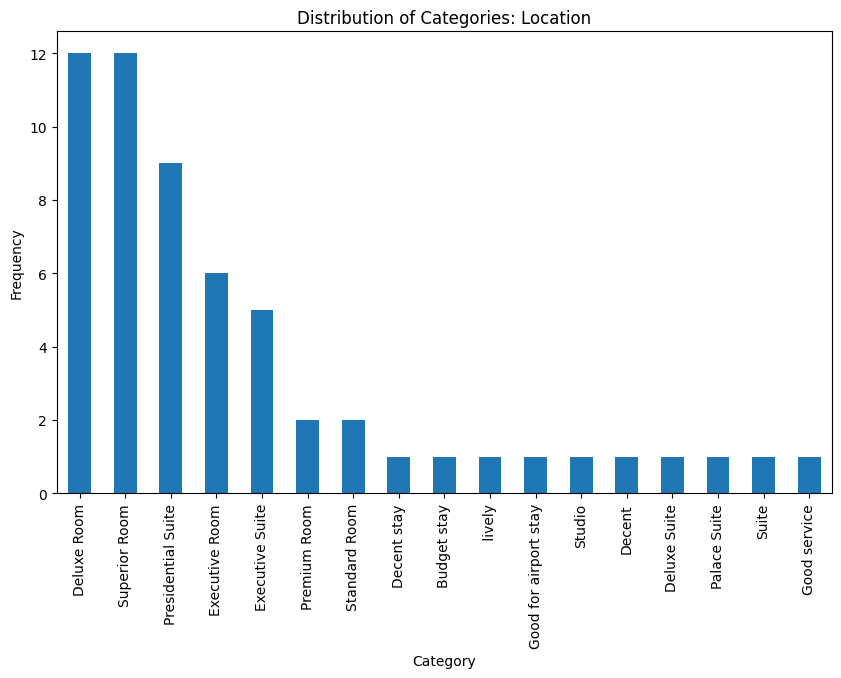

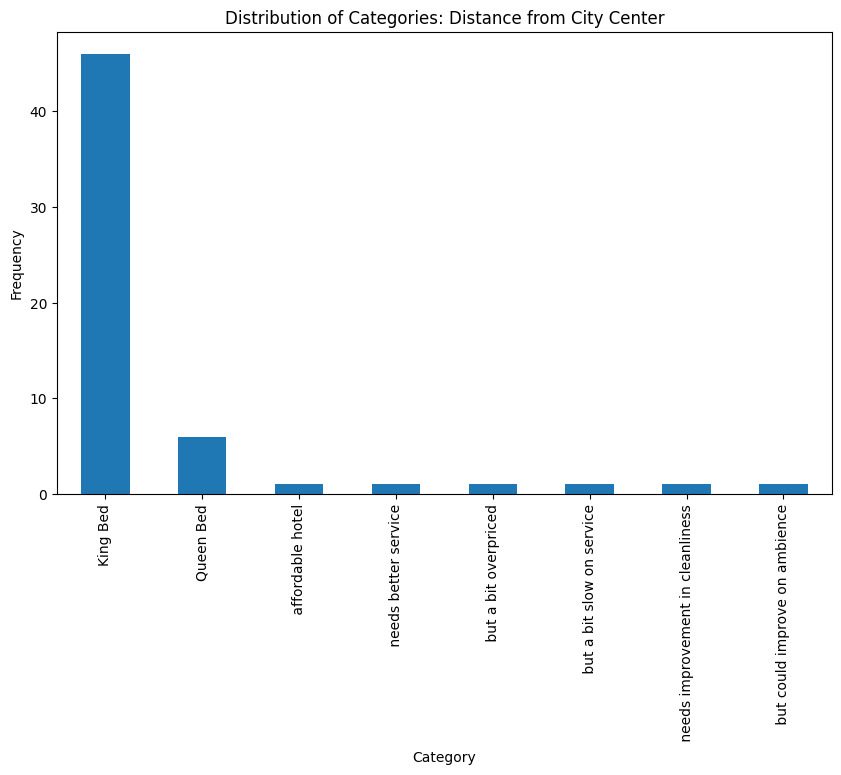

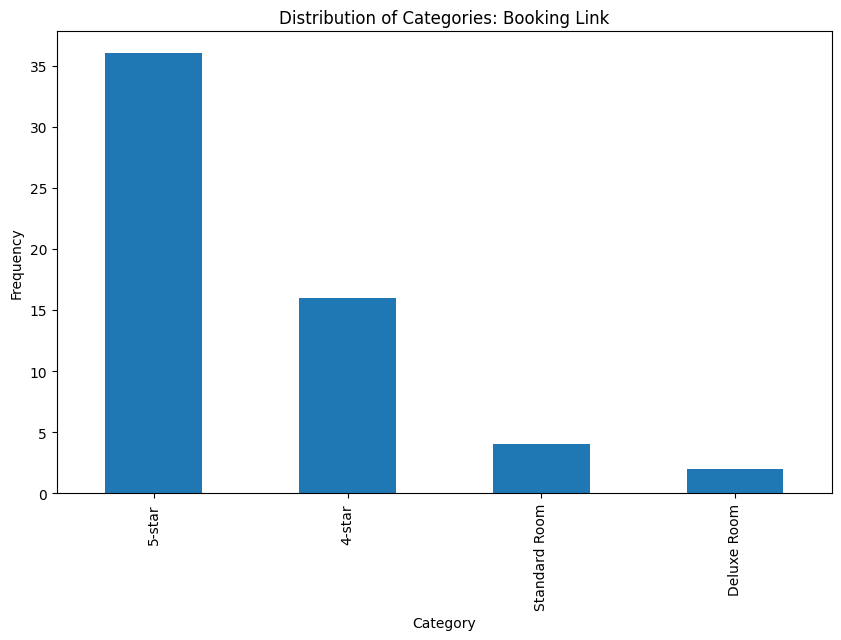

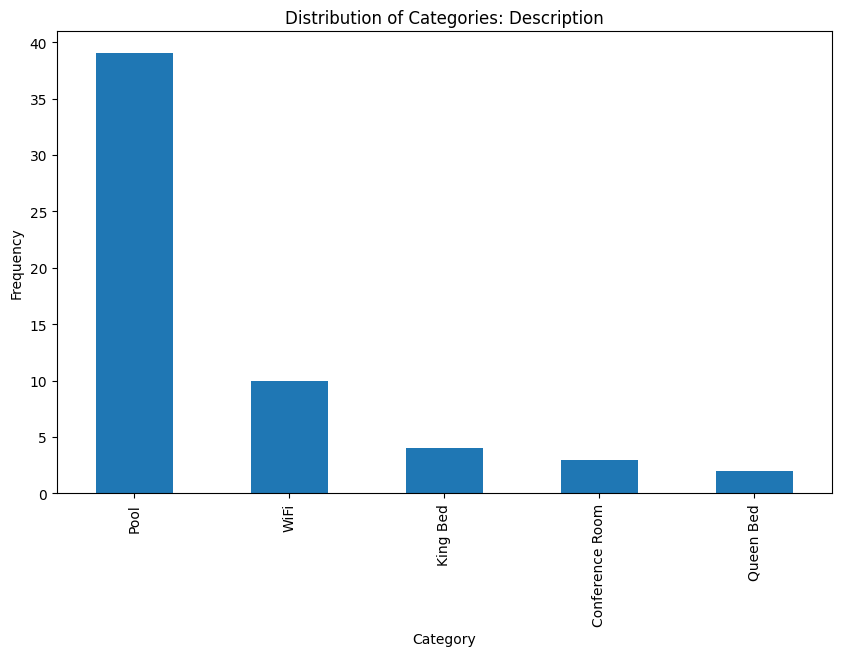

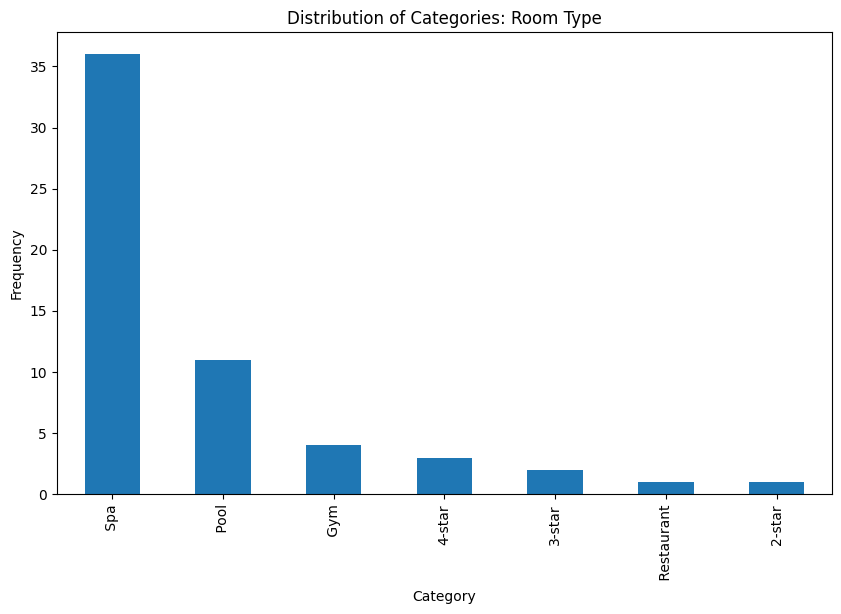

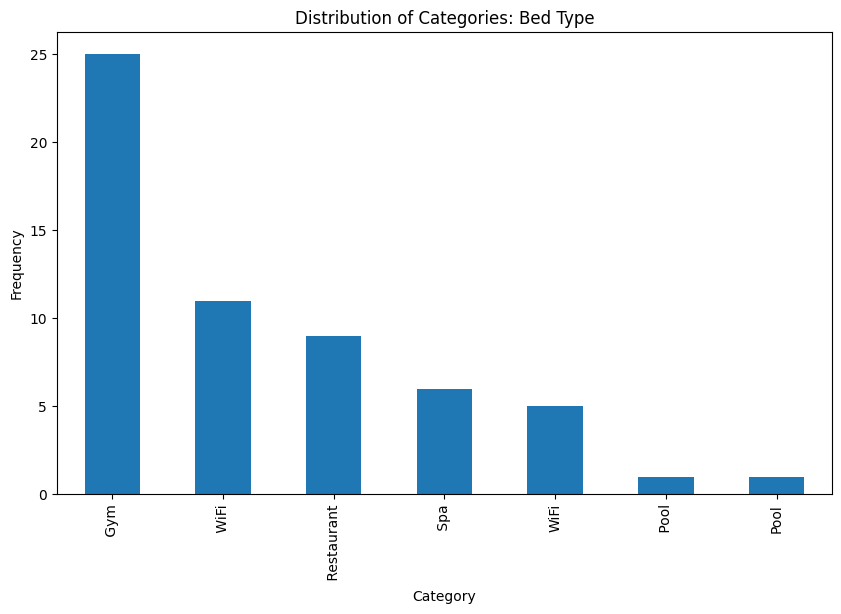

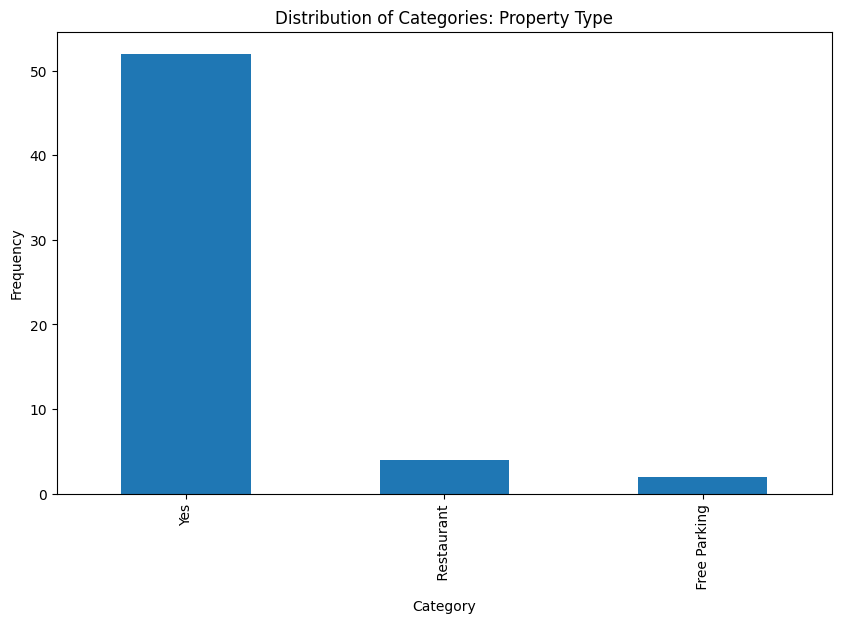

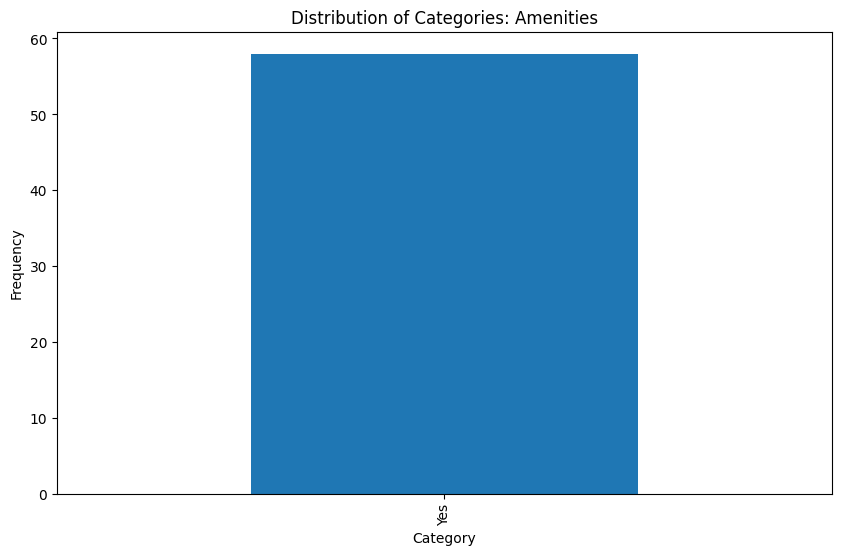

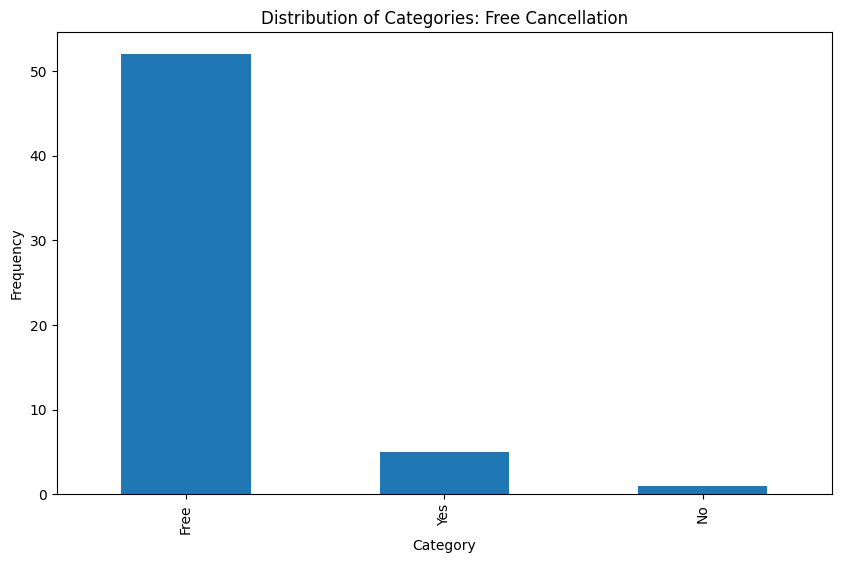

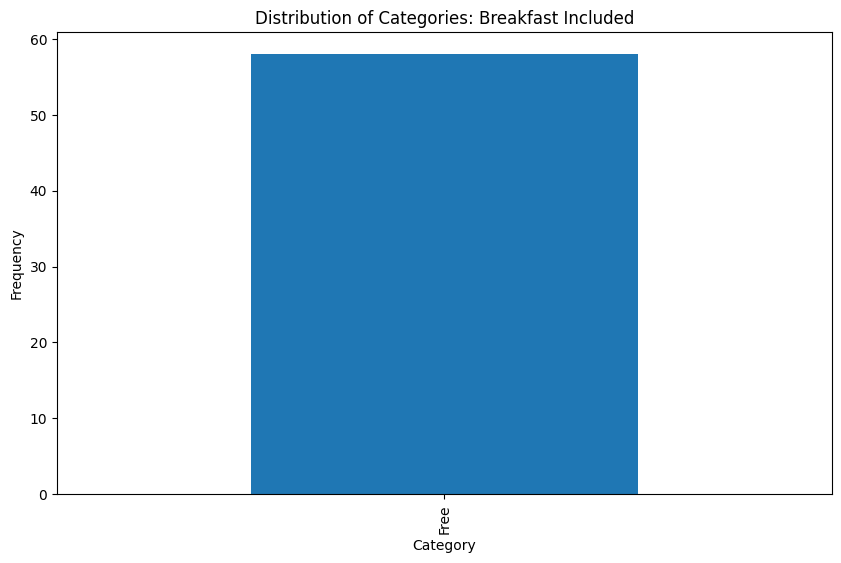

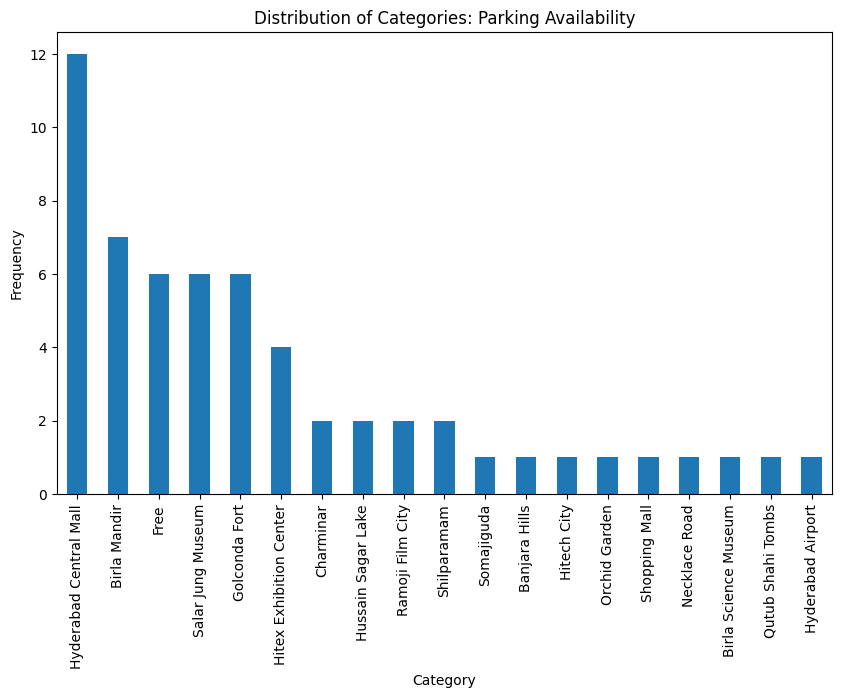

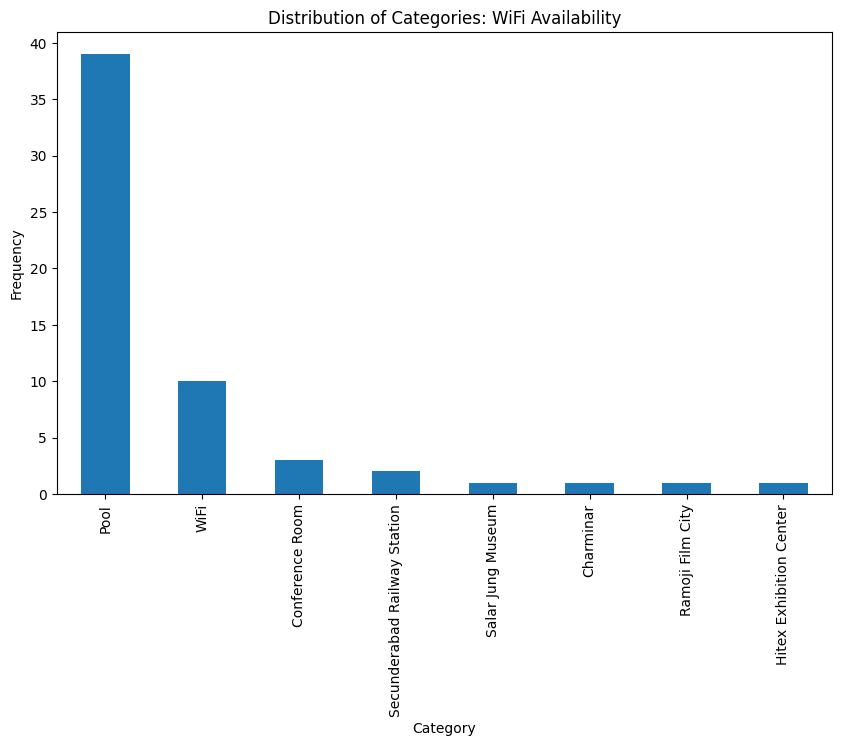

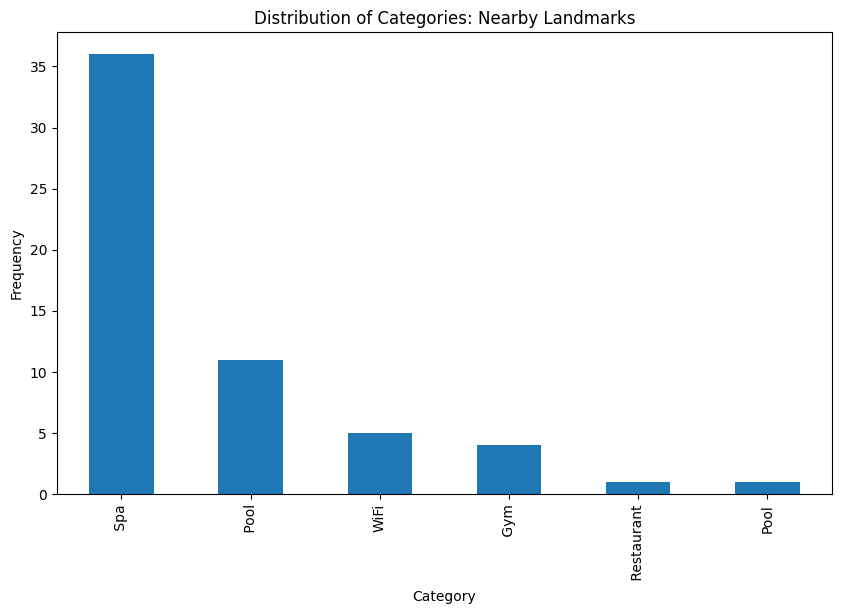

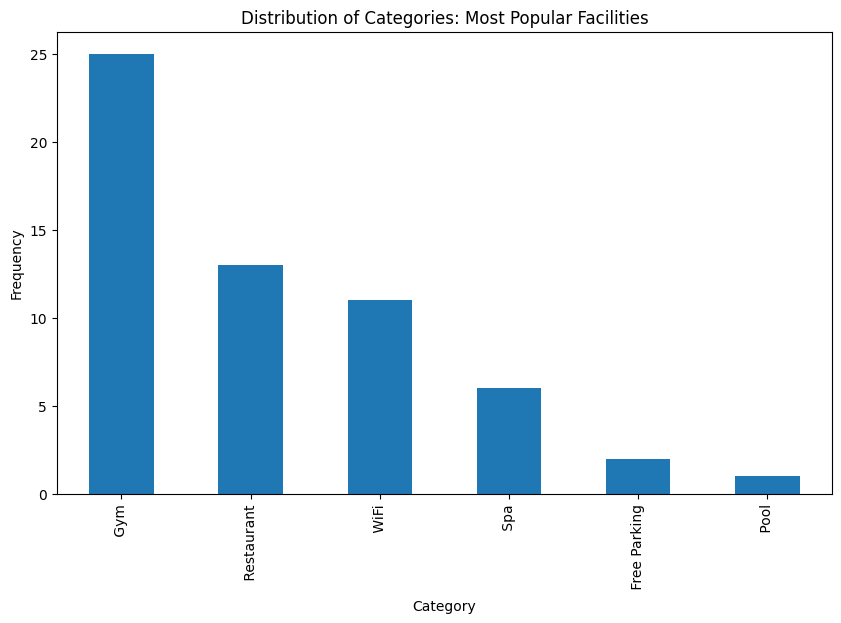

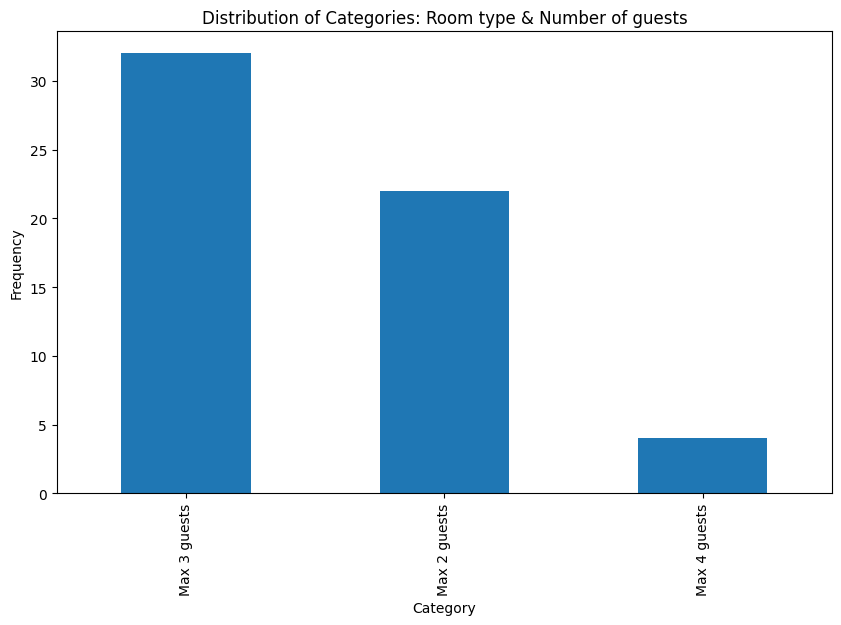

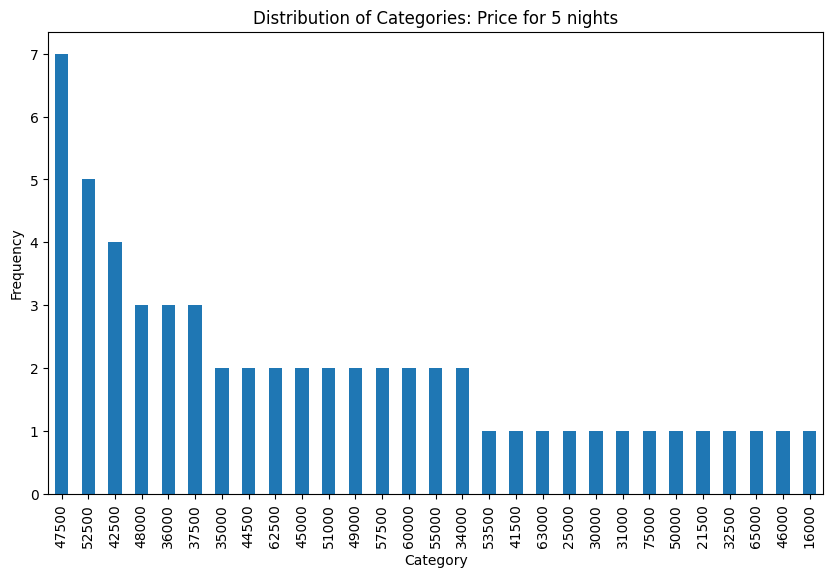

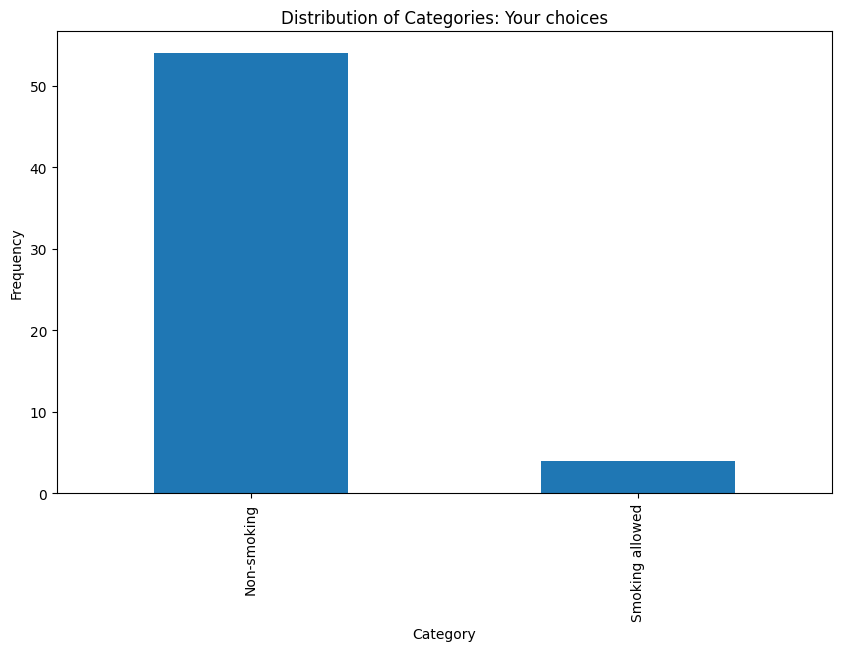

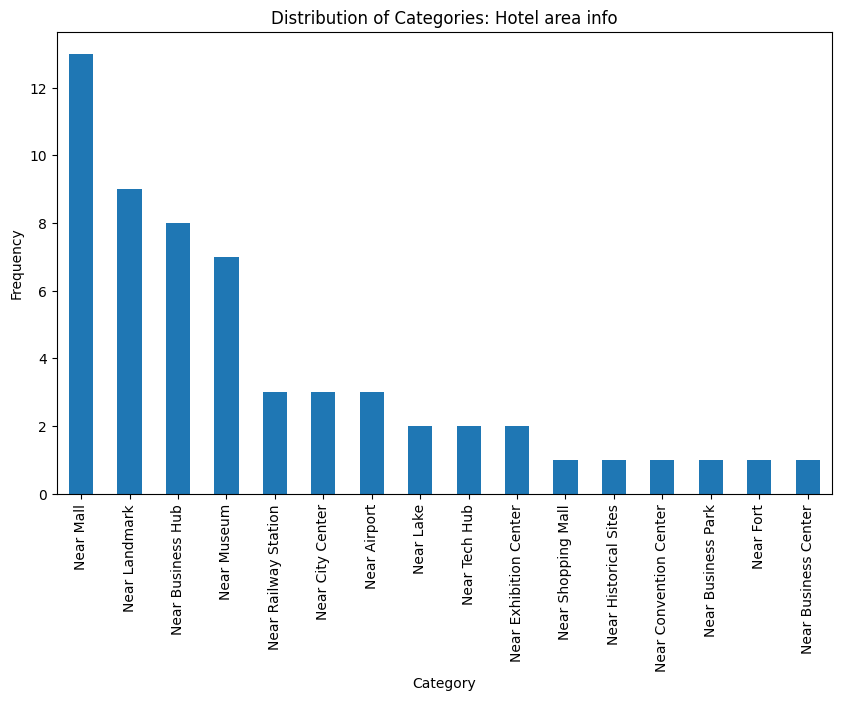


🔹 Correlation Matrix (Numeric Columns):
               Guest reviews
Guest reviews            1.0


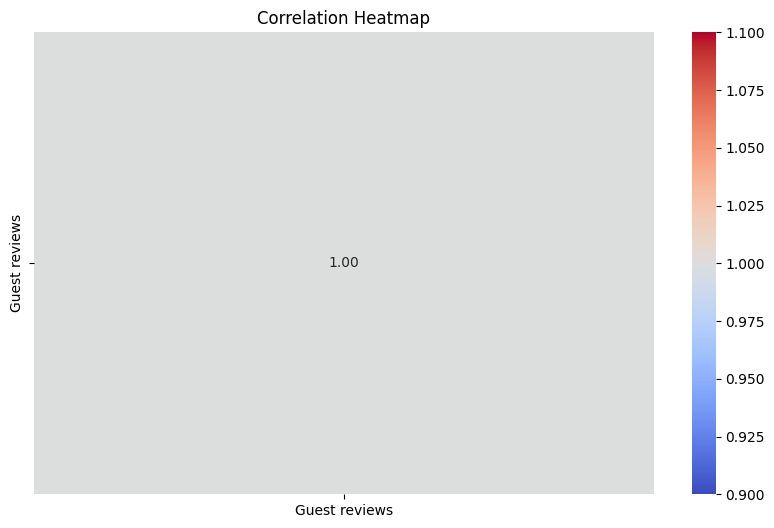

Skipping Hotel Name (too many categories)

 Identified Rating as a Categorical Column
Encoded as values: [ 5  8  7 11  6 15 12 14  0 13  1  2 10  9  4  3]

 Identified Price as a Categorical Column
Encoded as values: [ 6  8  9 10 11  1  3 12  4 14  5 13  2 15  7  0]
Skipping Total Reviews (too many categories)
Skipping Review Summary (too many categories)

 Identified Location as a Categorical Column
Encoded as values: [ 4 13 12 15 10 16  6 11 14  5  7  2  3  8  0  1  9]

 Identified Distance from City Center as a Categorical Column
Encoded as values: [6 7 0 4 1 2 5 3]

 Identified Booking Link as a Categorical Column
Encoded as values: [1 0 3 2]

 Identified Description as a Categorical Column
Encoded as values: [2 0 4 3 1]

 Identified Room Type as a Categorical Column
Encoded as values: [0 3 2 1 5 6 4]

 Identified Bed Type as a Categorical Column
Encoded as values: [3 4 2 0 1 6 5]

 Identified Property Type as a Categorical Column
Encoded as values: [2 0 1]

 Identified Amenities a

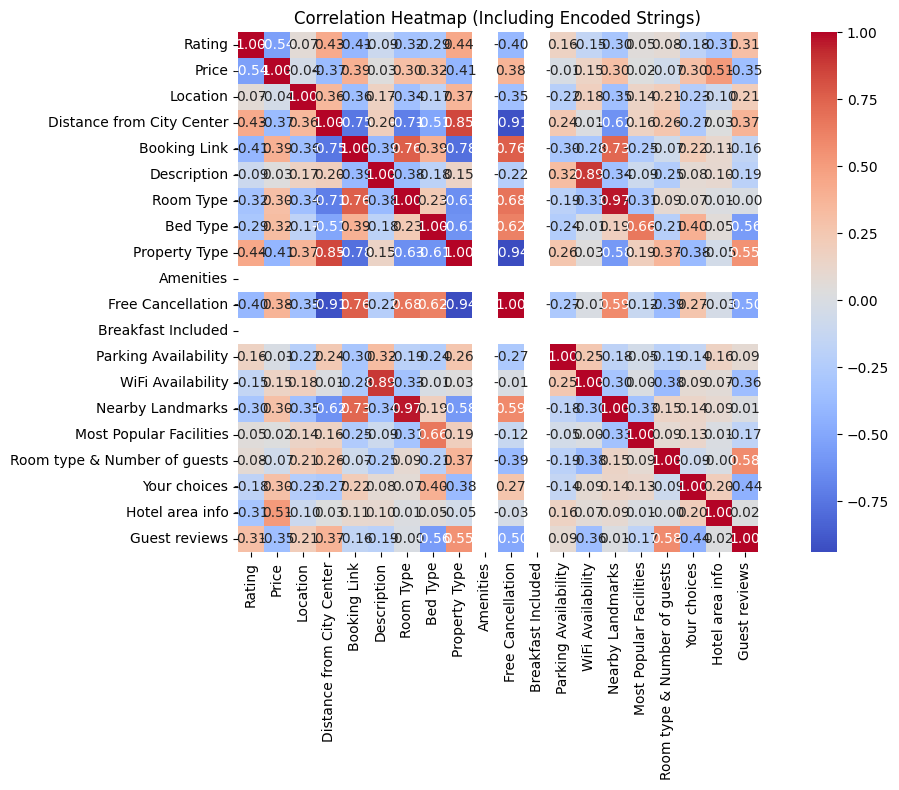


✅ EDA complete.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive')

def eda_report_hotels(csv_file_path, na_values=None):
    if na_values is None:
        na_values = ["None", "none", "NA", "N/A", "n/a", "null", "NULL", "-", ""]

    print(f"\n📥 Reading file: {csv_file_path}")
    # Use the 'on_bad_lines' argument to skip bad lines (instead of 'error_bad_lines' which is deprecated)
    df = pd.read_csv(csv_file_path, na_values=na_values, on_bad_lines='skip')

    # 1. BASIC OVERVIEW
    print("\n🔹 Basic Info:")
    print(df.info())

    print("\n🔹 First 5 rows:")
    print(df.head())

    print("\n🔹 Shape:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    # 2. SUMMARY STATISTICS
    print("\n🔹 Summary Statistics (Numeric):")
    print(df.describe())

    print("\n🔹 Summary Statistics (Object / Categorical):")
    print(df.describe(include='object'))

    # 3. CONVERT TO CORRECT DATATYPES
    print("\n🔹 Column Types:")
    print(df.dtypes)

    # 4. HANDLE MISSING VALUES
    print("\n🔹 Missing Values Per Column:")
    print(df.isnull().sum())
    print("\n🔹 Missing Values Per Row:")
    print(df.isnull().sum(axis=1))

    # Remove rows with missing values (if needed)
    df = df.dropna()
    print("\n🔹 Shape after removing missing values:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    # 5. IDENTIFY AND REMOVE DUPLICATE ROWS
    print("\n🔹 Number of Duplicate Rows:")
    print(df.duplicated().sum())

    print("\n🔹 Print Duplicate Rows:")
    df['group_id'] = df.groupby(df.columns.tolist(), dropna=True).ngroup()  # Create group IDs
    duplicate_rows = df[df.duplicated(keep=False)]  # Get the actual duplicate rows
    duplicate_rows = duplicate_rows.sort_values(by=['group_id'])

    # Print the group ID and the number of duplicate rows
    print("\n🔹 Duplicate Rows:")
    print(duplicate_rows)

    print("\n🔹 Group Counts:")
    print(duplicate_rows['group_id'].value_counts().sort_index())

    # Drop duplicates
    df = df.drop_duplicates(keep='first')
    df = df.drop(columns=['group_id'])

    print("\n🔹 Shape after removing duplicates:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    # 6. DATA CLEANING CHECKS
    print("\n🔹 Unique Values Per Column:")
    for col in df.columns:
        print(f"{col}: {df[col].unique()}")
        print("-" * 20)  # Print a separator line

    # 7. VISUALISE DATA AS PLOTS TO IDENTIFY OUTLIERS AND ANOMALIES
    print("\n📊 Generating basic plots...")

    # Histogram of all numeric columns
    df.hist(figsize=(12, 8), bins=20)
    plt.suptitle('Histograms of Numeric Columns')
    plt.tight_layout()
    plt.show()

    # Bar Chart for non-numeric columns like objects and strings
    for col in df.select_dtypes(include=['object', 'string']):
        category_counts = df[col].value_counts()
        category_counts.plot(kind='bar', figsize=(10, 6))
        plt.title(f'Distribution of Categories: {col}')
        plt.xlabel('Category')
        plt.ylabel('Frequency')
        plt.show()

    # 8. PERFORM CORRELATIONS TO IDENTIFY DEPENDENT FEATURES
    print("\n🔹 Correlation Matrix (Numeric Columns):")
    corr = df.corr(numeric_only=True)
    print(corr)

    # Heatmap of correlations
    if not corr.empty:
        plt.figure(figsize=(10, 6))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Correlation Heatmap")
        plt.show()

    # 9. IDENTIFY COLUMNS WHICH CAN BE CONVERTED TO CATEGORICAL VALUES AND PERFORM CORRELATIONS
    # Step 1: Make a copy to encode
    df_encoded = df.copy()

    # Step 2: Encode string columns
    for col in df_encoded.select_dtypes(include=['object', 'string']):
        if df_encoded[col].nunique() < 20:  # Avoid high-cardinality
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            print(f"\n Identified {col} as a Categorical Column")
            print(f"Encoded as values: {df_encoded[col].unique()}")
        else:
            print(f"Skipping {col} (too many categories)")
            df_encoded.drop(columns=[col], inplace=True)

    # Step 3: Correlation matrix for encoded columns
    corr_encoded = df_encoded.corr(numeric_only=True)

    # Step 4: Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_encoded, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation Heatmap (Including Encoded Strings)")
    plt.tight_layout()
    plt.show()

    print("\n✅ EDA complete.")

    return df_encoded  # Return the cleaned dataframe

# Example usage:
df = eda_report_hotels("/content/drive/MyDrive/MLops/hyderabad_hotels.csv")  # Use your hotel data CSV file path

# Save the cleaned dataframe into a new csv file
df.to_csv("/content/drive/MyDrive/MLops/hotels_data_cleaned.csv", index=False)
